#### produce regulon plots for fetal and disease in ggplot

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
fetal_res_df = read.csv("04B_fetal_sig_regulon_df.csv")

In [10]:
fetal_res_df$shortened_regulon <- sub("_.*", "", fetal_res_df$regulon)

In [12]:
fetal_res_df$log_padj <- -log10(fetal_res_df$padj)

In [13]:
fetal_res_df <- fetal_res_df %>%
  mutate(direction = ifelse(log2FC < 0, "negative", "positive"))

In [14]:
filt_positive_res_df <- fetal_res_df[fetal_res_df$log2FC > 0.5, ]

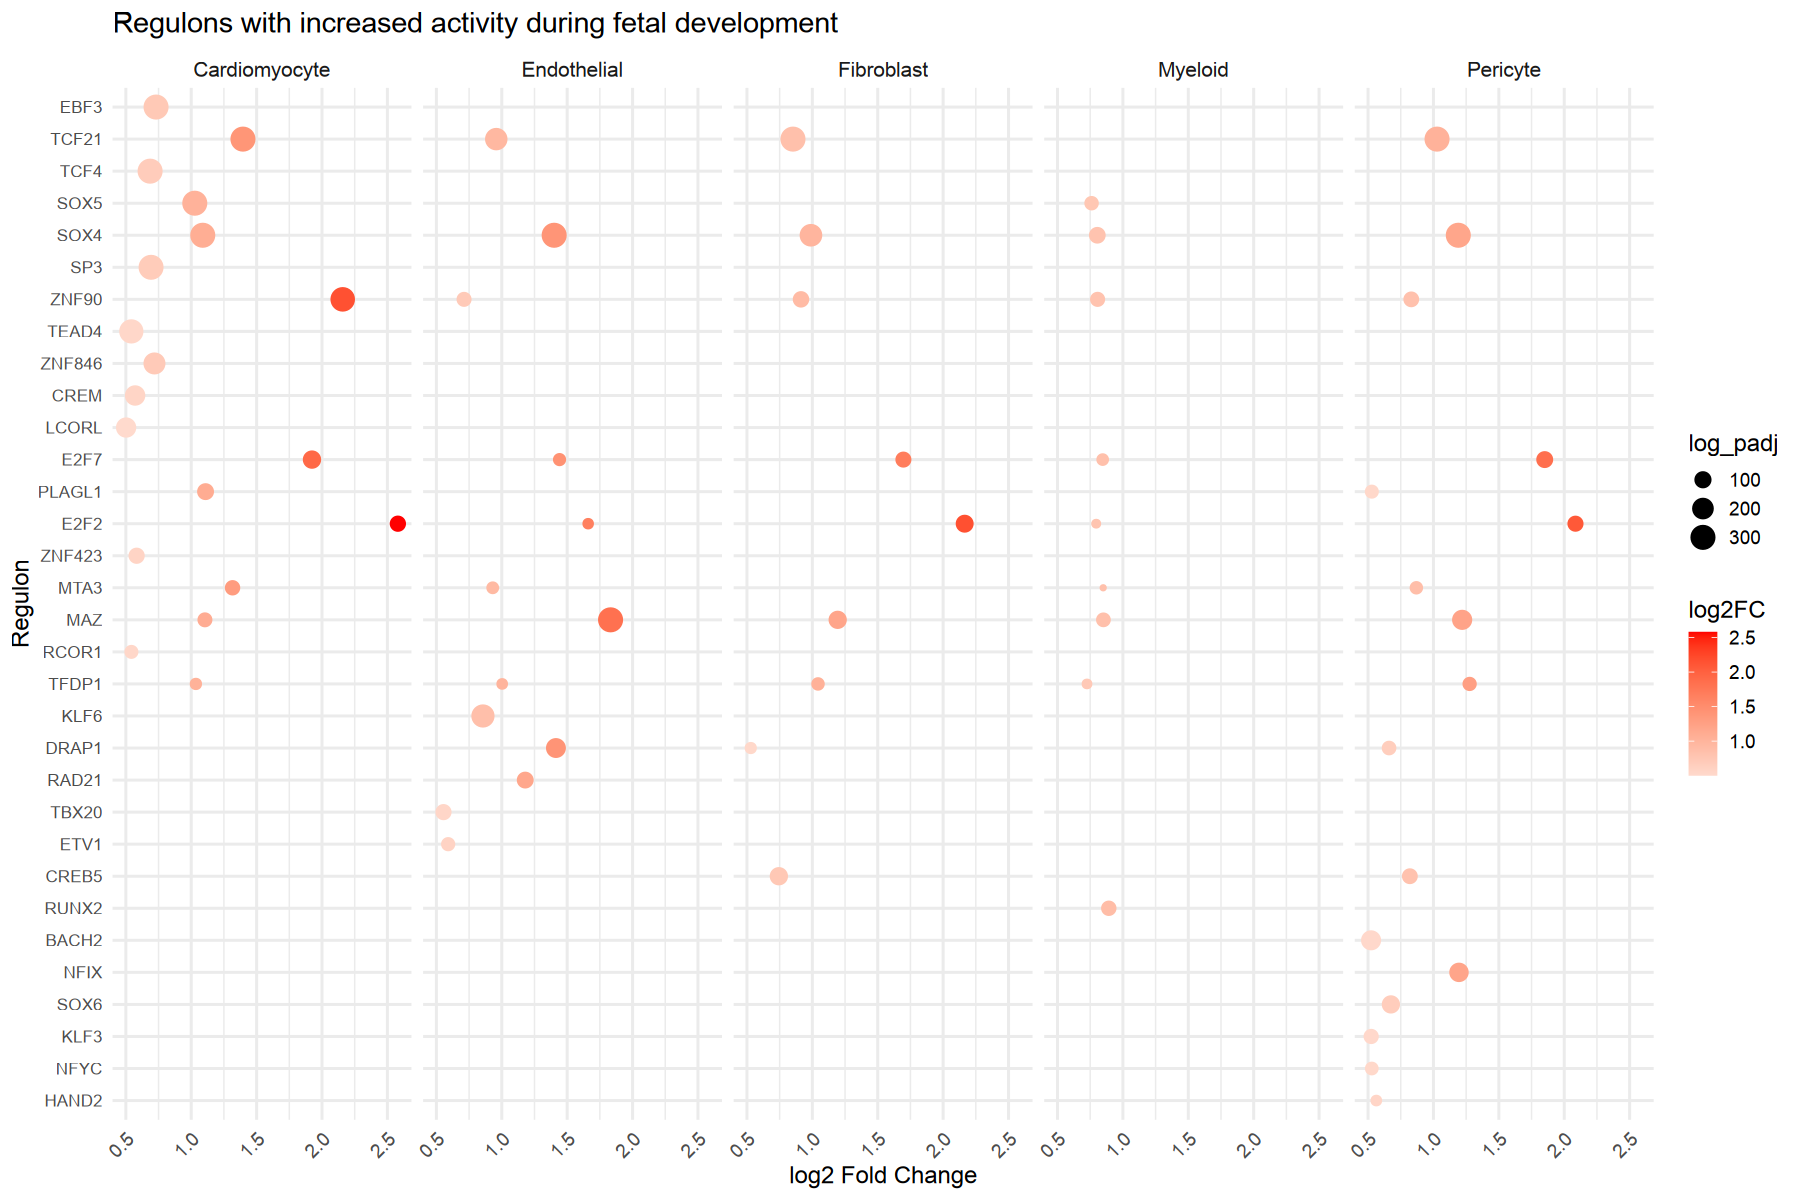

In [28]:
options(repr.plot.width = 15, repr.plot.height = 10)

filt_positive_res_df$shortened_regulon <- factor(
  filt_positive_res_df$shortened_regulon,
  levels = sort(unique(filt_positive_res_df$shortened_regulon))
)

p1 <- ggplot(data = filt_positive_res_df, 
       mapping = aes(x = log2FC, y = shortened_regulon, size = log_padj, color = log2FC)) +
  geom_point() + 
  facet_grid(~cell_type) + 
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0,
                        name = "log2FC") +
  theme_minimal(base_size = 14) +              
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "right"
  ) +
  labs(
    x = "log2 Fold Change",
    y = "Regulon",
    title = "Regulons with increased activity during fetal development"
  )

p1 

ggsave(p1, filename = "04C_fetal_up_GRNs.pdf", height = 10, width = 15)

In [24]:
filt_negative_res_df <- fetal_res_df[fetal_res_df$log2FC < -0.5, ]

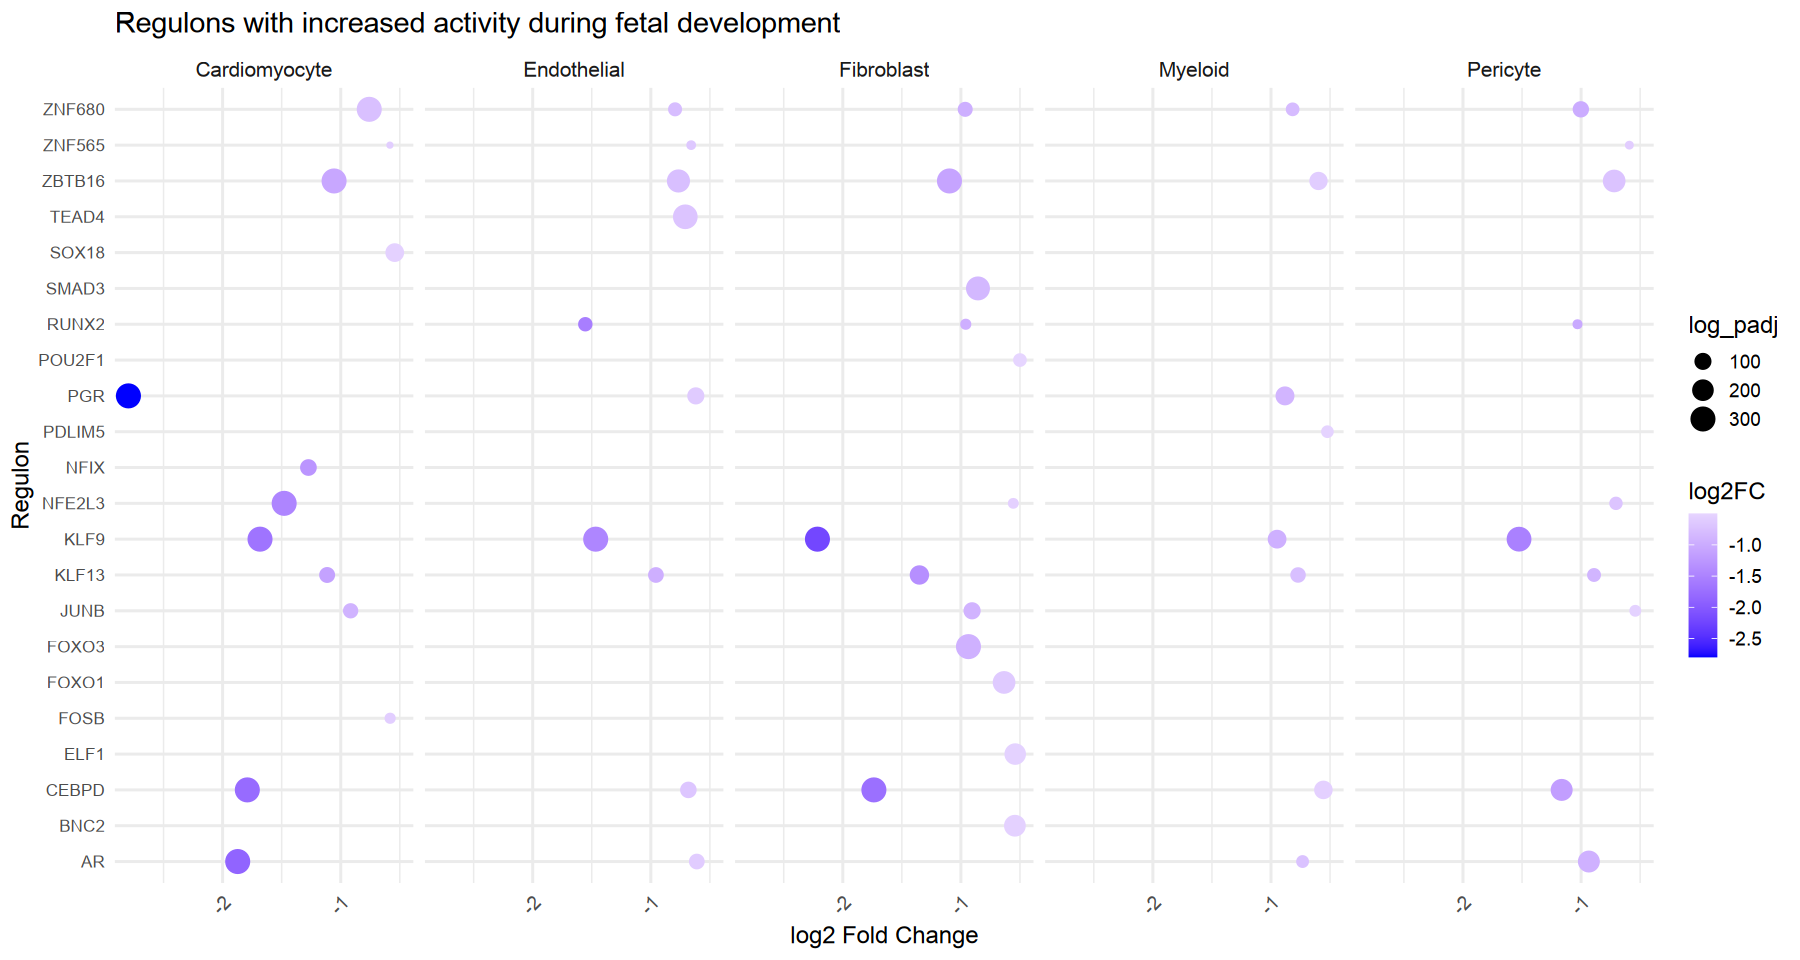

In [30]:
options(repr.plot.width = 15, repr.plot.height = 8)

filt_negative_res_df$shortened_regulon <- factor(
  filt_negative_res_df$shortened_regulon,
  levels = sort(unique(filt_negative_res_df$shortened_regulon))
)

p2 <- ggplot(data = filt_negative_res_df, 
       mapping = aes(x = log2FC, y = shortened_regulon, size = log_padj, color = log2FC)) +
  geom_point() + 
  facet_grid(~cell_type) + 
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0,
                        name = "log2FC") +
  theme_minimal(base_size = 14) +              
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "right"
  ) +
  labs(
    x = "log2 Fold Change",
    y = "Regulon",
    title = "Regulons with increased activity during fetal development"
  )

ggsave(p2, filename = "04C_fetal_down_GRNs.pdf", height = 8, width = 15)

p2